In [1]:
import pandas as pd

df = pd.read_csv("ashrae_db.csv")
df

C:\Users\samue\AppData\Local\Temp\ipykernel_20668\1787217667.py:3: DtypeWarning: Columns (10,11,13,18,19,34,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ashrae_db.csv")


,Publication (Citation),Data contributor,Year,Season,Koppen climate classification,Climate,City,Country,Building type,Cooling startegy_building level,...,Subject«s height (cm),Subject«s weight (kg),Blind (curtain),Fan,Window,Door,Heater,Outdoor monthly air temperature (C),Outdoor monthly air temperature (F),Database
0,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,162.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
1,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,154.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
2,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,173.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
3,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,167.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
4,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,178.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107578,"Kwok, A.G. ""Thermal Comfort in Tropical Classr...",Alison Kwok,1996.0,Winter,As,Tropical dry savanna,Honolulu,USA,Classroom,Air Conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Database 1
107579,"Kwok, A.G. ""Thermal Comfort in Tropical Classr...",Alison Kwok,1996.0,Winter,As,Tropical dry savanna,Honolulu,USA,Classroom,Air Conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Database 1
107580,"Kwok, A.G. ""Thermal Comfort in Tropical Classr...",Alison Kwok,1996.0,Winter,As,Tropical dry savanna,Honolulu,USA,Classroom,Air Conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Database 1
107581,"Kwok, A.G. ""Thermal Comfort in Tropical Classr...",Alison Kwok,1996.0,Winter,As,Tropical dry savanna,Honolulu,USA,Classroom,Air Conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Database 1


In [2]:
cols_to_use = [
    'Thermal comfort',
    'Clo',
    'Met',
    'Air temperature (C)',
    'Relative humidity (%)',
    'Air velocity (m/s)',
    'Season',
    'Koppen climate classification',
    'Building type',
    'Cooling startegy_building level',
    'Cooling startegy_operation mode for MM buildings'
]



df = df[cols_to_use]
df = df.dropna(subset=['Thermal comfort'])
df = df.drop_duplicates()


cols_to_unknown = [
    'Season',
    'Koppen climate classification',
    'Building type',
    'Cooling startegy_building level',
    'Cooling startegy_operation mode for MM buildings'
]
df[cols_to_unknown] = df[cols_to_unknown].fillna('Unknown')


df.isna().sum()

Thermal comfort                                        0
Clo                                                  828
Met                                                 3838
Air temperature (C)                                 3652
Relative humidity (%)                               1283
Air velocity (m/s)                                  5001
Season                                                 0
Koppen climate classification                          0
Building type                                          0
Cooling startegy_building level                        0
Cooling startegy_operation mode for MM buildings       0
dtype: int64

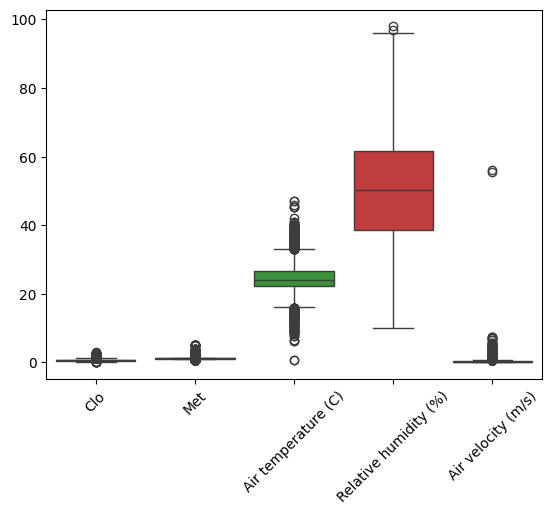

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    col for col in df.columns
    if col not in cols_to_unknown and col != 'Thermal comfort'
]

sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from sklearn.impute import KNNImputer

climate_col = 'Koppen climate classification'

le = LabelEncoder()
climate_idx  = le.fit_transform(df[climate_col])   # integer array, aligned to df
n_climates   = len(le.classes_)
climate_names = le.classes_


df = df.copy().reset_index(drop=True)              # clean index before imputation

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])

In [5]:
cols_to_encode = [c for c in cols_to_unknown if c != climate_col]

# encode categorical columns
df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# ensure target is numeric
df_encoded['Thermal comfort'] = pd.to_numeric(df['Thermal comfort'], errors='coerce')

valid_mask  = df_encoded['Thermal comfort'].notna()
df_encoded  = df_encoded[valid_mask].reset_index(drop=True)
climate_idx = climate_idx[valid_mask]

In [6]:
# See exactly what non-numeric values exist
tc = df['Thermal comfort'].astype(str).str.strip()
non_numeric = tc[pd.to_numeric(tc, errors='coerce').isna()].value_counts()
print("Non-numeric Thermal comfort values:\n", non_numeric)

# Strip whitespace, replace junk with NaN, then convert
df['Thermal comfort'] = (
    df['Thermal comfort']
    .astype(str)
    .str.strip()
    .replace({'Na': np.nan, 'nan': np.nan, '': np.nan, ' ': np.nan})
    .pipe(pd.to_numeric, errors='coerce')
)

print("After fix:", df['Thermal comfort'].dtype)


Non-numeric Thermal comfort values:
 Thermal comfort
      6
Na    1
Name: count, dtype: int64
After fix: float64


In [7]:
unknown_masks = {col: df[col] == 'Unknown' for col in cols_to_unknown}

print("Overlap between Unknown groups:")
for col_a, mask_a in unknown_masks.items():
    for col_b, mask_b in unknown_masks.items():
        if col_a >= col_b:
            continue
        overlap = (mask_a & mask_b).sum()
        if overlap > 0:
            print(f"  {col_a[:30]} ∩ {col_b[:30]} = {overlap} rows")

Overlap between Unknown groups:
  Cooling startegy_building leve ∩ Cooling startegy_operation mod = 256 rows
  Cooling startegy_operation mod ∩ Season = 92 rows


In [8]:
df = df[df['Thermal comfort'].between(1, 6)].reset_index(drop=True)

season_unknown_idx = df[
    (df['Season'] == 'Unknown') &
    (df['Building type'] == 'Multifamily housing') &
    (df['Koppen climate classification'] == 'BSh')
].index
df = df.drop(index=season_unknown_idx).reset_index(drop=True)

print(f"Rows remaining: {len(df)}")

Rows remaining: 31205


In [9]:
# Check the scale
print("Unique Thermal comfort values (sorted):")
print(sorted(df['Thermal comfort'].dropna().unique()))

Unique Thermal comfort values (sorted):
[np.float64(1.0), np.float64(1.3), np.float64(1.5), np.float64(1.7), np.float64(1.8), np.float64(2.0), np.float64(2.2), np.float64(2.3), np.float64(2.4), np.float64(2.5), np.float64(2.6), np.float64(2.7), np.float64(2.8), np.float64(3.0), np.float64(3.4), np.float64(3.5), np.float64(4.0), np.float64(4.2), np.float64(4.3), np.float64(4.5), np.float64(5.0), np.float64(5.1), np.float64(5.2), np.float64(6.0)]


In [10]:
# arrays for model
X = df_encoded.drop(columns=['Thermal comfort', climate_col]).values.astype(float)
y = df_encoded['Thermal comfort'].values.astype(float)

feature_names = df_encoded.drop(
    columns=['Thermal comfort', climate_col]
).columns.tolist()

print(f"X shape       : {X.shape}")
print(f"y shape       : {y.shape}")
print(f"climate_idx   : {climate_idx.shape}")
print(f"n_climates    : {n_climates}  →  {climate_names}")
print(f"Features ({len(feature_names)})  : {feature_names}")
assert len(X) == len(climate_idx), "Row mismatch — something went wrong!"

X shape       : (31301, 18)
y shape       : (31301,)
climate_idx   : (31301,)
n_climates    : 16  →  ['Af' 'Am' 'As' 'Aw' 'BSh' 'BSk' 'BWh' 'Cfa' 'Cfb' 'Csa' 'Csb' 'Csc' 'Cwa'
 'Cwb' 'Dfb' 'Dwa']
Features (18)  : ['Clo', 'Met', 'Air temperature (C)', 'Relative humidity (%)', 'Air velocity (m/s)', 'Season_Spring', 'Season_Summer', 'Season_Unknown', 'Season_Winter', 'Building type_Multifamily housing', 'Building type_Office', 'Building type_Others', 'Building type_Senior center', 'Cooling startegy_building level_Mixed Mode', 'Cooling startegy_building level_Naturally Ventilated', 'Cooling startegy_building level_Unknown', 'Cooling startegy_operation mode for MM buildings_Naturally Ventilated', 'Cooling startegy_operation mode for MM buildings_Unknown']


In [11]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax.numpy as jnp
from jax import random

numpyro.set_platform("cpu")
numpyro.set_host_device_count(4)




X_run           = X
y_run           = y
climate_idx_run = climate_idx
print(f"Running on full dataset: {len(X)} rows")

#Convert to JAX arrays

X_jnp          = jnp.array(X_run,           dtype=jnp.float32)
y_jnp          = jnp.array(y_run,           dtype=jnp.float32)
climate_jnp    = jnp.array(climate_idx_run, dtype=jnp.int32)


def hierarchical_model(X, climate_idx, y=None):
    n_features = X.shape[1]

    # Global priors
    beta      = numpyro.sample("beta",      dist.Normal(0, 1).expand([n_features]))
    intercept = numpyro.sample("intercept", dist.Normal(0, 1))
    sigma     = numpyro.sample("sigma",     dist.HalfNormal(1))

    # Climate random intercepts — non-centered
    mu_climate    = numpyro.sample("mu_climate",    dist.Normal(0, 1))
    sigma_climate = numpyro.sample("sigma_climate", dist.HalfNormal(1))

    climate_offset_raw = numpyro.sample(
        "climate_offset_raw",
        dist.Normal(0, 1).expand([n_climates])
    )
    climate_offset = mu_climate + sigma_climate * climate_offset_raw

    # Likelihood
    mu = intercept + jnp.dot(X, beta) + climate_offset[climate_idx]

    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)


kernel = NUTS(hierarchical_model)
mcmc   = MCMC(
    kernel,
    num_warmup=500,
    num_samples=1000,
    num_chains=4,
    progress_bar=True
)

mcmc.run(random.PRNGKey(42), X_jnp, climate_jnp, y_jnp)

c:\Users\samue\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on full dataset: 31301 rows


Compiling.. :   0%|          | 0/1500 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1500 [00:04<?, ?it/s]

In [12]:
import arviz as az

trace = az.from_numpyro(mcmc)

# Check convergence 
rhat = az.rhat(trace)
print("\nMax r_hat (convergence check):")
print({k: float(v.max()) for k, v in rhat.items()})

# Feature-level summary
beta_summary = az.summary(
    trace,
    var_names=["beta"],
    hdi_prob=0.95
)
beta_summary.index = feature_names

beta_summary['significant'] = (
    (beta_summary['hdi_2.5%'] > 0) | (beta_summary['hdi_97.5%'] < 0)
)

print("\nFeature coefficients:")
print(
    beta_summary[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'significant']]
    .sort_values('mean', key=abs, ascending=False)
    .to_string()
)

# Climate random effects
climate_summary = az.summary(trace, var_names=["climate_offset_raw"], hdi_prob=0.95)
climate_summary.index = [f"climate_{c}" for c in climate_names]
print("\nClimate random intercepts:")
print(climate_summary[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%']].to_string())




c:\Users\samue\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(

Running chain 0:   5%|▌         | 75/1500 [00:19<04:38,  5.11it/s]


Running chain 0:  10%|█         | 150/1500 [00:56<08:22,  2.68it/s]




Running chain 0:  20%|██        | 300/1500 [02:07<08:46,  2.28it/s]

Running chain 0:  25%|██▌       | 375/1500 [02:34<07:40,  2.44it/s]


Running chain 0:  30%|███       | 450/1500 [02:59<06:44,  2.59it/s]


Running chain 0:  35%|███▌      | 525/1500 [03:35<06:43,  2.42it/s]


Running chain 0:  40%|████      | 600/1500 [04:12<06:36,  2.27it/s]


Running chain 0:  45%|████▌     | 675/1500 [04:48<06:13,  2.21it/s]


Running chain 0:  55%|█████▌    


Max r_hat (convergence check):
{'beta': 1.0061975548393391, 'climate_offset_raw': 1.0125339654230905, 'intercept': 1.0018793946683344, 'mu_climate': 1.001651637086656, 'sigma': 1.0016857175496983, 'sigma_climate': 1.001252763430012}

Feature coefficients:
                                                                        mean     sd  hdi_2.5%  hdi_97.5%  significant
Season_Unknown                                                        -0.756  0.126    -1.013     -0.522         True
Cooling startegy_operation mode for MM buildings_Unknown              -0.609  0.035    -0.675     -0.541         True
Cooling startegy_building level_Mixed Mode                            -0.519  0.034    -0.584     -0.454         True
Building type_Senior center                                            0.481  0.066     0.347      0.606         True
Cooling startegy_building level_Unknown                               -0.373  0.079    -0.526     -0.218         True
Building type_Office               

In [13]:
import joblib

# save bayesian model
trace.to_netcdf('bayesian_trace.nc')           

beta_means = np.array(trace.posterior['beta'].mean(dim=('chain', 'draw')))
intercept_mean = float(trace.posterior['intercept'].mean())
mu_climate_mean = float(trace.posterior['mu_climate'].mean())
sigma_climate_mean = float(trace.posterior['sigma_climate'].mean())
offset_raw_means = np.array(trace.posterior['climate_offset_raw'].mean(dim=('chain', 'draw')))

climate_offset_means = mu_climate_mean + sigma_climate_mean * offset_raw_means

# the derived posterior means you use for prediction
np.savez(
    'bayesian_params.npz',
    beta_means          = beta_means,
    intercept_mean      = [intercept_mean],
    climate_offset_means= climate_offset_means,
    feature_names       = feature_names,
    climate_names       = climate_names
)

# scaler and imputer (needed to preprocess new data the same way)
joblib.dump(scaler,  'scaler.pkl')
joblib.dump(imputer, 'imputer.pkl')
joblib.dump(le,      'climate_label_encoder.pkl')

['climate_label_encoder.pkl']

In [14]:
import numpy as np

# ── Extract posterior means from trace ─────────────────────────────────────────





In [15]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import numpy as np


beta_means     = np.array(trace.posterior['beta'].mean(dim=('chain','draw')))
intercept_mean = float(trace.posterior['intercept'].mean())

# climate offset per observation
mu_climate_mean    = float(trace.posterior['mu_climate'].mean())
sigma_climate_mean = float(trace.posterior['sigma_climate'].mean())
offset_raw_means   = np.array(trace.posterior['climate_offset_raw'].mean(dim=('chain','draw')))
climate_offset_means = mu_climate_mean + sigma_climate_mean * offset_raw_means

y_pred_bayes = (
    intercept_mean
    + X_run @ beta_means
    + climate_offset_means[climate_idx_run]
)

rmse_b = root_mean_squared_error(y_run, y_pred_bayes)
mae_b  = mean_absolute_error(y_run, y_pred_bayes)
r2_b   = r2_score(y_run, y_pred_bayes)

print(f"Hierarchical Bayes — RMSE: {rmse_b:.4f} | MAE: {mae_b:.4f} | R²: {r2_b:.4f}")

Hierarchical Bayes — RMSE: 1.1564 | MAE: 0.9436 | R²: 0.2115


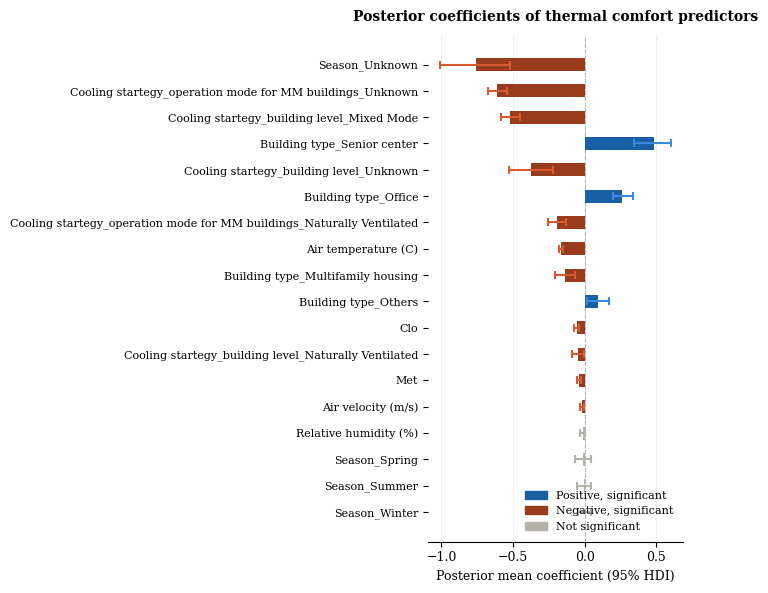

In [16]:
import matplotlib.patches as mpatches

# ── shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False,
})

sig_pos = '#185FA5'
sig_neg = '#993C1D'
insig   = '#B4B2A9'

legend_handles = [
    mpatches.Patch(color=sig_pos, label='Positive, significant'),
    mpatches.Patch(color=sig_neg, label='Negative, significant'),
    mpatches.Patch(color=insig,   label='Not significant'),
]

# ── Figure 1: feature forest plot ─────────────────────────────────────────────

order = beta_summary.sort_values('mean', key=abs, ascending=True)
labels  = order.index.tolist()
means_  = order['mean'].values
lo_     = order['hdi_2.5%'].values
hi_     = order['hdi_97.5%'].values
sig_    = order['significant'].values

colors = [sig_pos if (s and m>=0) else sig_neg if (s and m<0) else insig
          for m, s in zip(means_, sig_)]

fig, ax = plt.subplots(figsize=(7, 6))
y_pos = np.arange(len(labels))

for i, (m, l, h, c) in enumerate(zip(means_, lo_, hi_, colors)):
    ec = '#378ADD' if c == sig_pos else '#D85A30' if c == sig_neg else insig
    ax.barh(i, m, height=0.5, color=c, zorder=3)
    ax.errorbar(
        m, i,
        xerr=[[m - l], [h - m]],   # asymmetric: [[left_err], [right_err]]
        fmt='none',
        ecolor=ec,
        elinewidth=1.5,
        capsize=3,
        capthick=1.5,
        zorder=4
    )

ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5, zorder=2)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Posterior mean coefficient (95% HDI)', fontsize=9)
ax.set_title('Posterior coefficients of thermal comfort predictors', fontsize=10, fontweight='bold', pad=10)
ax.grid(axis='x', alpha=0.2, zorder=1)
ax.legend(handles=legend_handles, fontsize=8, frameon=False, loc='lower right')
ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('figure1_forest_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figure1_forest_plot.tiff', dpi=300, bbox_inches='tight')
plt.show()



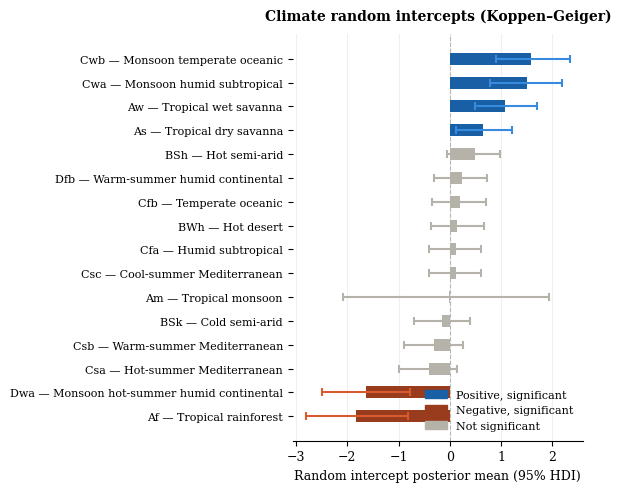

In [17]:
koppen_names = {
    'Af':  'Tropical rainforest',
    'Am':  'Tropical monsoon',
    'As':  'Tropical dry savanna',
    'Aw':  'Tropical wet savanna',
    'BSh': 'Hot semi-arid',
    'BSk': 'Cold semi-arid',
    'BWh': 'Hot desert',
    'BWk': 'Cold desert',
    'Cfa': 'Humid subtropical',
    'Cfb': 'Temperate oceanic',
    'Cfc': 'Subpolar oceanic',
    'Csa': 'Hot-summer Mediterranean',
    'Csb': 'Warm-summer Mediterranean',
    'Csc': 'Cool-summer Mediterranean',
    'Cwa': 'Monsoon humid subtropical',
    'Cwb': 'Monsoon temperate oceanic',
    'Cwc': 'Monsoon subpolar oceanic',
    'Dfa': 'Hot-summer humid continental',
    'Dfb': 'Warm-summer humid continental',
    'Dwa': 'Monsoon hot-summer humid continental',
    'Dwb': 'Monsoon warm-summer humid continental',
    'Dsa': 'Med. hot-summer humid continental',
    'Dsb': 'Med. warm-summer humid continental',
}

# apply to climate_summary index before sorting
climate_summary.index = [
    f"{code.replace('climate_', '')} — {koppen_names.get(code.replace('climate_', ''), code.replace('climate_', ''))}"
    for code in climate_summary.index
]

csig_ = (climate_summary['hdi_2.5%'] > 0) | (climate_summary['hdi_97.5%'] < 0)
c_order = climate_summary.sort_values('mean', ascending=True)
clabels = c_order.index.str.replace('climate_', '')
cmeans_ = c_order['mean'].values
clo_    = c_order['hdi_2.5%'].values
chi_    = c_order['hdi_97.5%'].values
csig_v  = csig_.loc[c_order.index].values

ccolors = [sig_pos if (s and m>=0) else sig_neg if (s and m<0) else insig
           for m, s in zip(cmeans_, csig_v)]


fig, ax = plt.subplots(figsize=(6, 5))
cy_pos = np.arange(len(clabels))

for i, (m, l, h, c) in enumerate(zip(cmeans_, clo_, chi_, ccolors)):
    ec = '#378ADD' if c == sig_pos else '#D85A30' if c == sig_neg else insig
    ax.barh(i, m, height=0.5, color=c, zorder=3)
    ax.errorbar(
        m, i,
        xerr=[[m - l], [h - m]],
        fmt='none',
        ecolor=ec,
        elinewidth=1.5,
        capsize=3,
        capthick=1.5,
        zorder=4
    )

ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5, zorder=2)
ax.set_yticks(cy_pos)
ax.set_yticklabels(clabels, fontsize=8)
ax.set_xlabel('Random intercept posterior mean (95% HDI)', fontsize=9)
ax.set_title('Climate random intercepts (Koppen–Geiger)', fontsize=10, fontweight='bold', pad=10)
ax.grid(axis='x', alpha=0.2, zorder=1)
ax.legend(handles=legend_handles, fontsize=8, frameon=False, loc='lower right')
ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('figure2_climate_intercepts.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figure2_climate_intercepts.tiff', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import RandomizedSearchCV

# add climate_idx as a feature so XGBoost sees the grouping

X_xgb          = np.hstack([X, climate_idx.reshape(-1, 1)])
feature_names_xgb = feature_names + ['climate_idx']

X_train, X_test, y_train, y_test, ci_train, ci_test = train_test_split(
    X_xgb, y, climate_idx,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (25040, 19), Test: (6261, 19)


In [19]:
param_grid = {
    'n_estimators'    : [300, 500, 800],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [3, 5, 6, 8],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.3],
    'reg_alpha'       : [0, 0.1, 0.5],      
    'reg_lambda'      : [1, 1.5, 2],        
}

base_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    base_score  = 0.5, 
    random_state=42,
    n_jobs=-1,
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator          = base_model,
    param_distributions= param_grid,
    n_iter             = 50,            
    scoring            = 'neg_root_mean_squared_error',
    cv                 = cv,
    random_state       = 42,
    n_jobs             = -1,
    verbose            = 3,
    refit              = True          
)

search.fit(X_train, y_train)

print(f"\nBest params: {search.best_params_}")
print(f"Best CV RMSE: {-search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 1.0}
Best CV RMSE: 1.0993


In [20]:
best_model = search.best_estimator_

best_model.save_model('xgboost_thermal_tuned.json')

cv_results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
cv_results.to_csv('xgboost_cv_results.csv', index=False)

y_pred_xgb = best_model.predict(X_test)

rmse_x = root_mean_squared_error(y_test, y_pred_xgb)
mae_x  = mean_absolute_error(y_test, y_pred_xgb)
r2_x   = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost (tuned) — RMSE: {rmse_x:.4f} | MAE: {mae_x:.4f} | R²: {r2_x:.4f}")


XGBoost (tuned) — RMSE: 1.0973 | MAE: 0.8821 | R²: 0.2973


In [21]:
import shap

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)  

shap_df = pd.DataFrame(shap_values, columns=feature_names_xgb)

# mean absolute SHAP per feature, global importance
shap_importance = pd.DataFrame({
    'feature'         : feature_names_xgb,
    'mean_abs_shap'   : np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 10 features by mean |SHAP|:")
print(shap_importance.head(10).to_string(index=False))


Top 10 features by mean |SHAP|:
                                                 feature  mean_abs_shap
                                             climate_idx       0.301522
                                    Building type_Office       0.233935
                                     Air temperature (C)       0.157868
              Cooling startegy_building level_Mixed Mode       0.085760
                                                     Clo       0.071871
                                   Relative humidity (%)       0.061127
Cooling startegy_operation mode for MM buildings_Unknown       0.052125
                                      Air velocity (m/s)       0.031200
                       Building type_Multifamily housing       0.028961
                                                     Met       0.026058


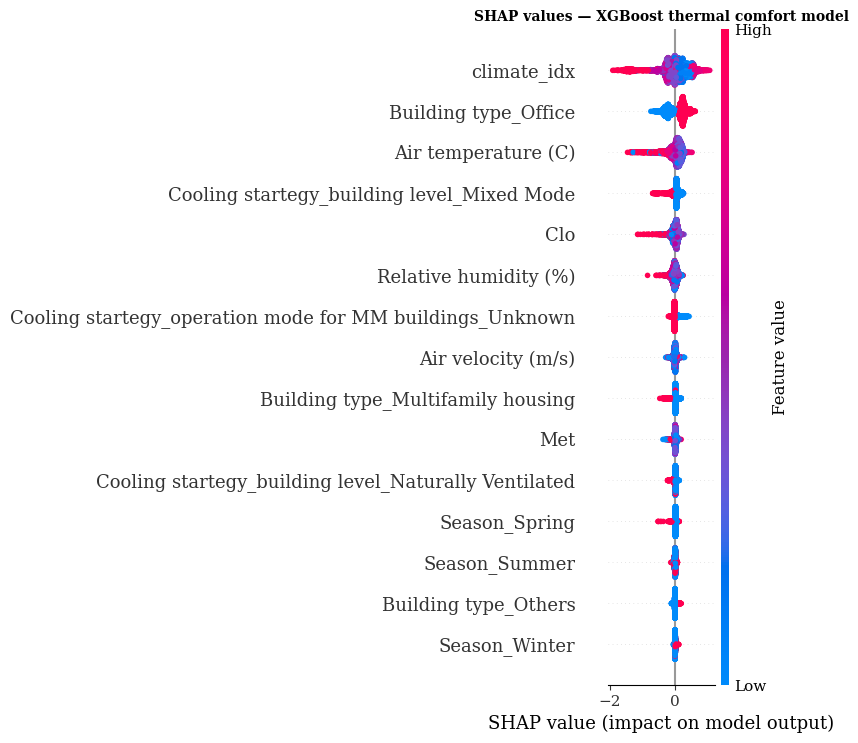

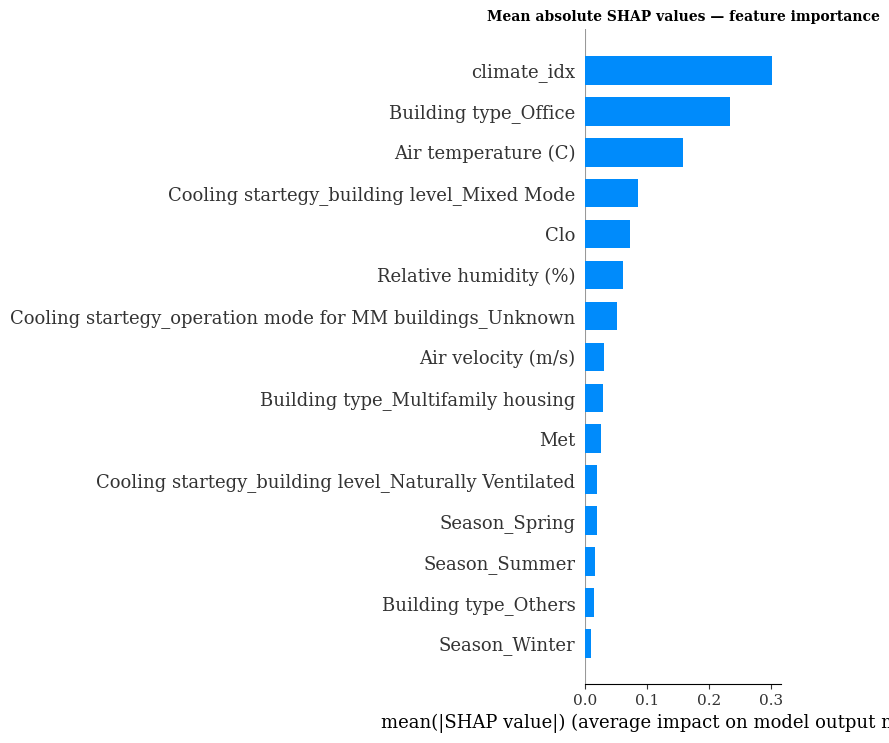

In [22]:
plt.rcParams.update({'font.family': 'serif', 'font.size': 9})


fig, ax = plt.subplots(figsize=(7, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names   = feature_names_xgb,
    max_display     = 15,              
    show            = False,
    plot_type       = 'dot'            
)
plt.title('SHAP values — XGBoost thermal comfort model', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('figure3_shap_beeswarm.pdf',  dpi=300, bbox_inches='tight')
plt.savefig('figure3_shap_beeswarm.tiff', dpi=300, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(7, 5))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names   = feature_names_xgb,
    max_display     = 15,
    show            = False,
    plot_type       = 'bar'
)
plt.title('Mean absolute SHAP values — feature importance', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('figure4_shap_bar.pdf',  dpi=300, bbox_inches='tight')
plt.savefig('figure4_shap_bar.tiff', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Compare Bayesian vs XGBoost on same test set

y_pred_bayes_test = (
    intercept_mean
    + X_test[:, :-1] @ beta_means          # drop climate_idx column
    + climate_offset_means[ci_test]
)

comparison = pd.DataFrame({
    'Model': ['Hierarchical Bayes', 'XGBoost (tuned)'],
    'RMSE' : [root_mean_squared_error(y_test, y_pred_bayes_test), rmse_x],
    'MAE'  : [mean_absolute_error(y_test, y_pred_bayes_test),     mae_x],
    'R²'   : [r2_score(y_test, y_pred_bayes_test),                r2_x],
})

print(comparison.to_string(index=False))
comparison.to_csv('model_comparison.csv', index=False)

             Model     RMSE      MAE       R²
Hierarchical Bayes 1.169656 0.960090 0.201535
   XGBoost (tuned) 1.097298 0.882138 0.297271
